In [2]:
# ================================
# 📦 INSTALLS (if needed)
# ================================
!pip install pyTsetlinMachine numpy pandas opencv-python scipy scikit-learn

# ================================
# 📦 IMPORTS
# ================================
import numpy as np
import cv2
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pyTsetlinMachine.tm import MultiClassConvolutionalTsetlinMachine2D as CTM

# ================================
# ⚙️ CONFIG
# ================================
N_SAMPLES = 1000
SIGNAL_LEN = 1024
IMG_SIZE = 100

CLAUSES = 200
T = 477
S = 2.081
PATCH_DIM = (10, 10)
MAX_LITERALS = 22
EPOCHS = 5
MONTE_CARLO_RUNS = 10  # increase later

# ================================
# 📡 SYNTHETIC DATA GENERATION
# ================================
def generate_clean_signal():
    t = np.linspace(0, 1, SIGNAL_LEN)

    freqs = np.random.uniform(5, 50, size=5)
    signal = sum(np.sin(2*np.pi*f*t) for f in freqs)

    return signal

def add_noise(signal):
    noise = np.random.normal(0, 0.5, size=signal.shape)
    return signal + noise

def add_jammer(signal):
    t = np.linspace(0, 1, SIGNAL_LEN)

    if np.random.rand() < 0.5:
        jammer = 3*np.sin(2*np.pi*80*t)  # tone jammer
    else:
        jammer = np.random.normal(0, 2, size=signal.shape)  # wideband jammer

    return signal + jammer

def create_dataset(n_samples):
    X = []
    y = []

    for _ in range(n_samples):
        signal = generate_clean_signal()
        signal = add_noise(signal)

        if np.random.rand() < 0.5:
            X.append(signal)
            y.append(0)  # no jammer
        else:
            X.append(add_jammer(signal))
            y.append(1)  # jammer present

    return np.array(X), np.array(y)

print("📡 Generating synthetic dataset...")
X_raw, y = create_dataset(N_SAMPLES)

# ================================
# 🔬 SPECTROGRAM GENERATION
# ================================
def compute_spectrogram(signal):
    f, t, Zxx = stft(signal, nperseg=128)
    spec = np.abs(Zxx)

    # Normalize safely
    spec = (spec - spec.min()) / (spec.max() + 1e-8)

    # Resize
    spec = cv2.resize(spec, (IMG_SIZE, IMG_SIZE))

    return spec

print("🔬 Generating spectrograms...")
X_spec = np.array([compute_spectrogram(x) for x in X_raw])

# ================================
# 🔥 ENHANCED OTSU BINARIZATION
# ================================
def enhanced_otsu(image):
    img = (image * 255).astype(np.uint8)

    _, th1 = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    img_rot = np.rot90(img)
    _, th2 = cv2.threshold(img_rot, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th2 = np.rot90(th2, k=3)

    return np.logical_or(th1, th2).astype(np.uint8)

print("🔥 Applying Enhanced Otsu...")
X_bin = np.array([enhanced_otsu(x) for x in X_spec])

# ================================
# ⚠️ IMPORTANT SHAPE FIX (CRITICAL)
# ================================
# CTM expects (samples, height, width)
X_bin = X_bin.astype(np.uint8)

print("Shape:", X_bin.shape)

# ================================
# 🔁 TRAINING FUNCTION
# ================================
def train_ctm(X_train, y_train, X_test, y_test):

    tm = CTM(
        number_of_clauses=CLAUSES,
        T=T,
        s=S,
        patch_dim=PATCH_DIM,
        max_included_literals=MAX_LITERALS
    )

    for epoch in range(EPOCHS):
        tm.fit(X_train, y_train, epochs=1)

    preds = tm.predict(X_test)
    acc = accuracy_score(y_test, preds)

    return acc

# ================================
# 🔁 MONTE CARLO EVALUATION
# ================================
results = []

print("\n🚀 Running Monte Carlo experiments...\n")

for run in range(MONTE_CARLO_RUNS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_bin, y, test_size=0.2, stratify=y
    )

    acc = train_ctm(X_train, y_train, X_test, y_test)
    results.append(acc)

    print(f"Run {run+1}: Accuracy = {acc:.4f}")

# ================================
# 📊 FINAL RESULTS
# ================================
mean_acc = np.mean(results)
std_acc = np.std(results)

print("\n==============================")
print("📊 FINAL RESULTS")
print("==============================")
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Std Dev: {std_acc:.4f}")

/bin/bash: /home/priyat/anaconda3/envs/tmu_cuda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
📡 Generating synthetic dataset...
🔬 Generating spectrograms...
🔥 Applying Enhanced Otsu...
Shape: (1000, 100, 100)

🚀 Running Monte Carlo experiments...

Run 1: Accuracy = 0.9450
Run 2: Accuracy = 0.9400
Run 3: Accuracy = 0.9750
Run 4: Accuracy = 0.9700
Run 5: Accuracy = 0.9400
Run 6: Accuracy = 0.9650
Run 7: Accuracy = 0.9900
Run 8: Accuracy = 0.9300
Run 9: Accuracy = 0.9250
Run 10: Accuracy = 0.9650

📊 FINAL RESULTS
Mean Accuracy: 0.9545
Std Dev: 0.0203


In [3]:
# ================================
# 📦 INSTALLS
# ================================
!pip install pyTsetlinMachine numpy opencv-python scikit-learn

# ================================
# 📦 IMPORTS
# ================================
import numpy as np
import cv2
import os
import random
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pyTsetlinMachine.tm import MultiClassConvolutionalTsetlinMachine2D as CTM

# ================================
# ⚙️ CONFIG
# ================================
BASE_DIR = "MSTAR-10-Classes"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = 100
TRAIN_PER_CLASS = None  # set e.g. 100 if needed

CLAUSES = 200
T = 477
S = 2.081
PATCH_DIM = (10, 10)
MAX_LITERALS = 22
EPOCHS = 5
MONTE_CARLO_RUNS = 10

# ================================
# 📡 SAR DATA LOADER (ADAPTED)
# ================================
def load_sar_split(folder, limit=None):
    X = []
    y = []

    classes = sorted(os.listdir(folder))

    for label, cname in enumerate(classes):
        class_path = os.path.join(folder, cname)

        if not os.path.isdir(class_path):
            continue

        paths = glob(os.path.join(class_path, "*"))

        if limit:
            paths = random.sample(paths, min(limit, len(paths)))

        for p in paths:
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # 🔥 LOG TRANSFORM (VERY IMPORTANT FOR SAR)
            img = np.log1p(img.astype(np.float32))

            # Normalize
            img = img / (img.max() + 1e-8)

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

print("📡 Loading SAR dataset...")

X_train_raw, y_train = load_sar_split(TRAIN_DIR, TRAIN_PER_CLASS)
X_test_raw, y_test   = load_sar_split(TEST_DIR)

print("Train shape:", X_train_raw.shape)
print("Test shape :", X_test_raw.shape)

# ================================
# 🔥 ENHANCED OTSU BINARIZATION
# ================================
def enhanced_otsu(image):
    img = (image * 255).astype(np.uint8)

    _, th1 = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    img_rot = np.rot90(img)
    _, th2 = cv2.threshold(img_rot, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th2 = np.rot90(th2, k=3)

    return np.logical_or(th1, th2).astype(np.uint8)

print("🔥 Applying Enhanced Otsu...")

X_train = np.array([enhanced_otsu(x) for x in X_train_raw])
X_test  = np.array([enhanced_otsu(x) for x in X_test_raw])

X_train = X_train.astype(np.uint8)
X_test  = X_test.astype(np.uint8)

print("Final shape:", X_train.shape)

# ================================
# 🧠 CTM TRAINING FUNCTION
# ================================
def train_ctm(X_train, y_train, X_test, y_test):

    tm = CTM(
        number_of_clauses=CLAUSES,
        T=T,
        s=S,
        patch_dim=PATCH_DIM,
        max_included_literals=MAX_LITERALS
    )

    for epoch in range(EPOCHS):
        tm.fit(X_train, y_train, epochs=1)

    preds = tm.predict(X_test)
    acc = accuracy_score(y_test, preds)

    return acc

# ================================
# 🔁 MONTE CARLO
# ================================
results = []

print("\n🚀 Running Monte Carlo experiments...\n")

for run in range(MONTE_CARLO_RUNS):

    # shuffle train set each run
    idx = np.random.permutation(len(X_train))
    X_tr = X_train[idx]
    y_tr = y_train[idx]

    acc = train_ctm(X_tr, y_tr, X_test, y_test)
    results.append(acc)

    print(f"Run {run+1}: Accuracy = {acc:.4f}")

# ================================
# 📊 RESULTS
# ================================
print("\n==============================")
print("📊 FINAL RESULTS")
print("==============================")

print(f"Mean Accuracy: {np.mean(results):.4f}")
print(f"Std Dev: {np.std(results):.4f}")

/bin/bash: /home/priyat/anaconda3/envs/tmu_cuda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
📡 Loading SAR dataset...
Train shape: (2747, 100, 100)
Test shape : (2425, 100, 100)
🔥 Applying Enhanced Otsu...
Final shape: (2747, 100, 100)

🚀 Running Monte Carlo experiments...

Run 1: Accuracy = 0.2153
Run 2: Accuracy = 0.1419
Run 3: Accuracy = 0.2470
Run 4: Accuracy = 0.2536
Run 5: Accuracy = 0.2173
Run 6: Accuracy = 0.1827
Run 7: Accuracy = 0.1814
Run 8: Accuracy = 0.1254
Run 9: Accuracy = 0.2664
Run 10: Accuracy = 0.2487

📊 FINAL RESULTS
Mean Accuracy: 0.2080
Std Dev: 0.0462


Training TM: 4 pos + 4 neg clauses, 64-state FSA, 40% noisy XOR, 10000 epochs
  Epoch      1  |  Test accuracy: 73.8%
  Epoch     10  |  Test accuracy: 73.8%
  Epoch     50  |  Test accuracy: 73.8%
  Epoch    100  |  Test accuracy: 73.8%
  Epoch    500  |  Test accuracy: 73.8%
  Epoch   1000  |  Test accuracy: 73.8%
  Epoch   2000  |  Test accuracy: 73.8%
  Epoch   5000  |  Test accuracy: 73.8%
  Epoch  10000  |  Test accuracy: 73.8%

Final test accuracy: 73.8%


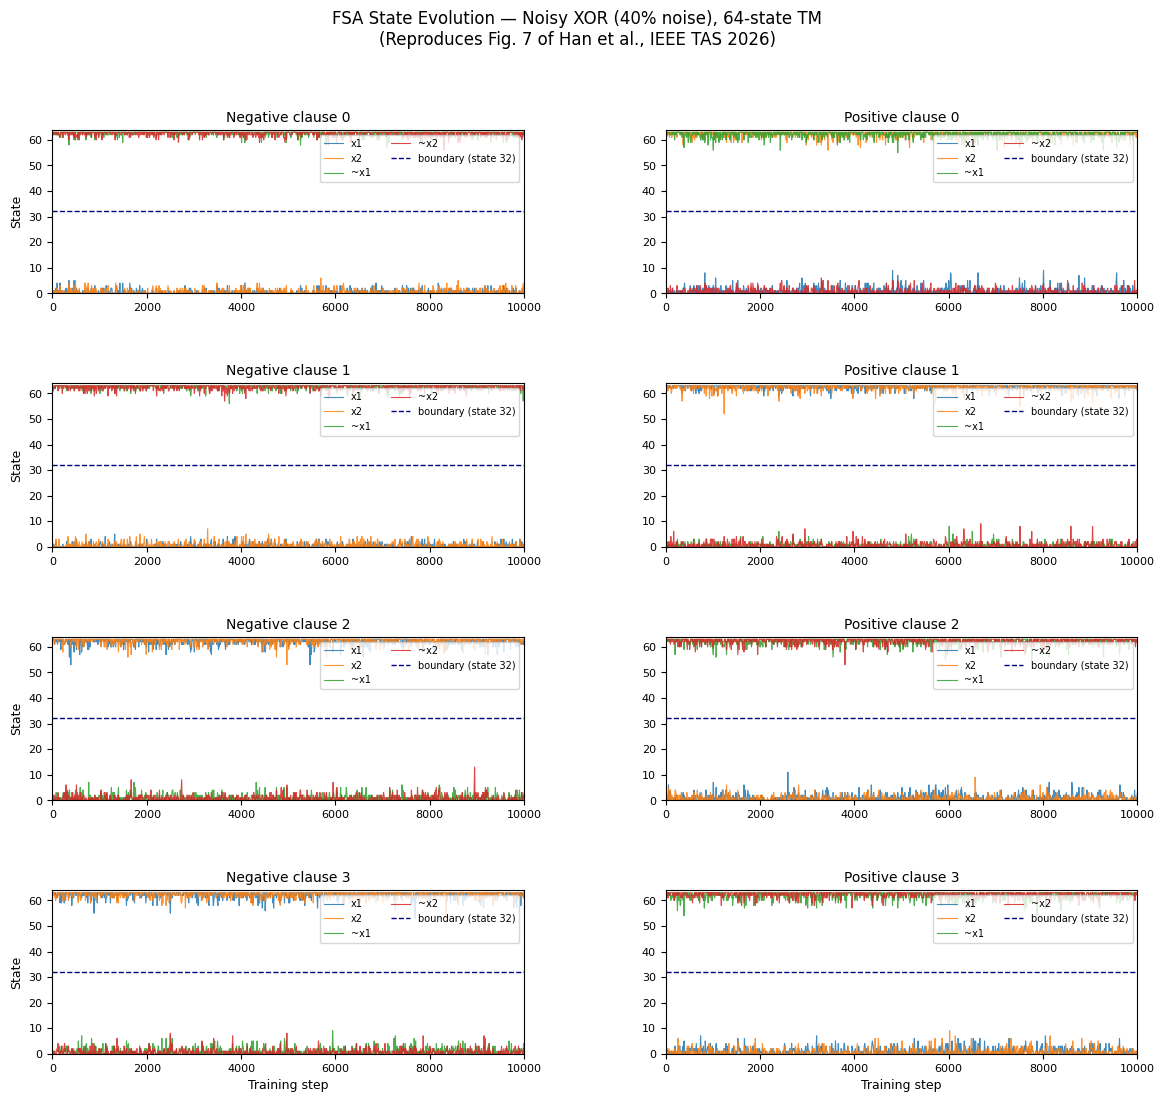

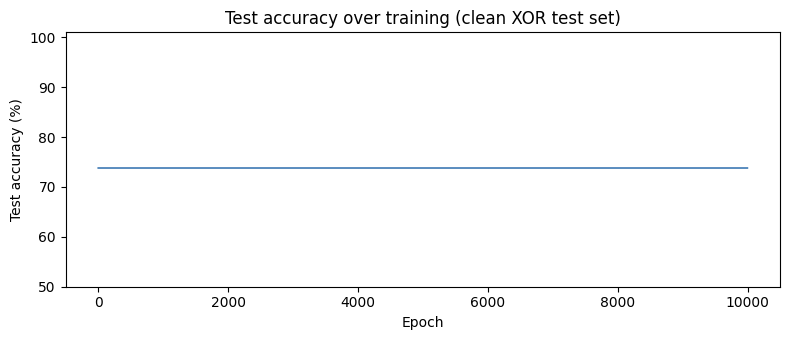


═══════════════════════════════════════════════
Learned clause logic (included literals only):
═══════════════════════════════════════════════
  Neg clause 0: ~x1 ∧ ~x2
  Neg clause 1: ~x1 ∧ ~x2
  Neg clause 2: x1 ∧ x2
  Neg clause 3: x1 ∧ x2
  Pos clause 0: x2 ∧ ~x1
  Pos clause 1: x1 ∧ x2
  Pos clause 2: ~x1 ∧ ~x2
  Pos clause 3: ~x1 ∧ ~x2

XOR truth table (learned model):
  x1=0, x2=0  →  pred=0  true=0  ✓
  x1=0, x2=1  →  pred=1  true=1  ✓
  x1=1, x2=0  →  pred=0  true=1  ✗
  x1=1, x2=1  →  pred=0  true=0  ✓


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy

# ─────────────────────────────────────────────────────────────
# 1.  DATASET  —  Noisy XOR with 40% noise  (as in the paper)
# ─────────────────────────────────────────────────────────────
np.random.seed(42)

def generate_noisy_xor(n_samples=1000, noise_rate=0.40):
    """Binary features x1, x2; label = XOR(x1,x2) flipped with 40% noise."""
    x1 = np.random.randint(0, 2, n_samples)
    x2 = np.random.randint(0, 2, n_samples)
    X  = np.column_stack([x1, x2])
    y  = (x1 ^ x2).astype(int)
    flip = np.random.rand(n_samples) < noise_rate
    y[flip] = 1 - y[flip]
    return X, y

X_train, y_train = generate_noisy_xor(2000, 0.40)
X_test,  y_test  = generate_noisy_xor(500,  0.00)   # clean test set


# ─────────────────────────────────────────────────────────────
# 2.  HC-RDFF  — High-Capacity Resettable D Flip-Flop
#     Emulates the cascaded-storage-loop FSA cell from §II
# ─────────────────────────────────────────────────────────────
class HCRDFF:
    """
    Models the HC-RDFF described in Fig. 2 of the paper.
    States 0..N-1  →  EXCLUDE action
    States N..2N-1 →  INCLUDE action
    'up' input  increments state (reward side)
    'down' input decrements state (penalty side)
    Boundary saturation at 0 and 2N-1.
    """
    def __init__(self, N=32):
        self.N     = N
        self.state = N - 1          # start at boundary (exclude side)

    def step(self, signal):
        """signal: +1 (up/reward) or -1 (down/penalty)"""
        self.state = np.clip(self.state + signal, 0, 2 * self.N - 1)

    @property
    def action(self):
        return 1 if self.state >= self.N else 0   # 1=include, 0=exclude

    @property
    def normalized_state(self):
        return self.state / (2 * self.N - 1)


# ─────────────────────────────────────────────────────────────
# 3.  CLAUSE  — propositional clause built from HC-RDFF FSAs
# ─────────────────────────────────────────────────────────────
class Clause:
    def __init__(self, n_features, N=32):
        self.n_features = n_features
        # One FSA per literal (feature and its negation)
        self.fsas = [HCRDFF(N) for _ in range(2 * n_features)]

    def get_included_literals(self):
        return [i for i, fsa in enumerate(self.fsas) if fsa.action == 1]

    def evaluate(self, x):
        """Returns 1 if all included literals are satisfied, else 0."""
        x_lit = np.concatenate([x, 1 - x])   # [x1,x2,..., ~x1,~x2,...]
        included = self.get_included_literals()
        if len(included) == 0:
            return 0
        return int(all(x_lit[i] == 1 for i in included))

    def train(self, x, vote, clause_output, s=3.9):
        """
        Tsetlin Machine type-I / type-II feedback (§II of paper).
        s: specificity parameter (controls how tight clauses become).
        """
        x_lit = np.concatenate([x, 1 - x])
        for i, fsa in enumerate(self.fsas):
            if vote == 1:
                # Type-I feedback
                if clause_output == 1:
                    if x_lit[i] == 1:
                        fsa.step(+1)          # reward include
                    else:
                        fsa.step(-1)          # penalise include
                else:
                    if np.random.rand() < 1.0 / s:
                        if x_lit[i] == 1:
                            fsa.step(+1)
                        else:
                            fsa.step(-1)
            else:
                # Type-II feedback
                if clause_output == 1:
                    if x_lit[i] == 0 and fsa.action == 1:
                        fsa.step(-1)


# ─────────────────────────────────────────────────────────────
# 4.  TSETLIN MACHINE  —  4 pos + 4 neg clauses  (paper §III)
# ─────────────────────────────────────────────────────────────
class TsetlinMachine:
    """
    Binary TM with C positive and C negative clauses.
    Paper uses C=4, N=32 (64-state FSA = 2*N states), 10000 epochs.
    """
    def __init__(self, n_features=2, C=4, N=32, T=4):
        self.C          = C
        self.T          = T    # voting threshold
        self.pos_clauses = [Clause(n_features, N) for _ in range(C)]
        self.neg_clauses = [Clause(n_features, N) for _ in range(C)]
        self.n_features = n_features

    def predict(self, x):
        pos_sum = sum(c.evaluate(x) for c in self.pos_clauses)
        neg_sum = sum(c.evaluate(x) for c in self.neg_clauses)
        return 1 if pos_sum > neg_sum else 0

    def fit_one(self, x, y):
        pos_votes = [c.evaluate(x) for c in self.pos_clauses]
        neg_votes = [c.evaluate(x) for c in self.neg_clauses]
        v = np.clip(sum(pos_votes) - sum(neg_votes), -self.T, self.T)

        for i, c in enumerate(self.pos_clauses):
            if np.random.rand() <= (self.T - v) / (2 * self.T):
                c.train(x, vote=y, clause_output=pos_votes[i])

        for i, c in enumerate(self.neg_clauses):
            if np.random.rand() <= (self.T + v) / (2 * self.T):
                c.train(x, vote=1 - y, clause_output=neg_votes[i])

    def accuracy(self, X, y):
        preds = [self.predict(x) for x in X]
        return np.mean(np.array(preds) == y) * 100


# ─────────────────────────────────────────────────────────────
# 5.  TRAINING  —  10 000 epochs  (exactly as in paper)
# ─────────────────────────────────────────────────────────────
EPOCHS    = 10_000
C_CLAUSES = 4        # paper: 4 pos + 4 neg
N_STATES  = 32       # paper: 64-state FSA  →  N=32 gives 2N=64 states
T         = 4        # voting threshold

tm = TsetlinMachine(n_features=2, C=C_CLAUSES, N=N_STATES, T=T)

# Capture FSA state history for Fig. 7 reproduction
history_pos = [[[] for _ in range(C_CLAUSES)] for _ in range(2 * 2)]
history_neg = [[[] for _ in range(C_CLAUSES)] for _ in range(2 * 2)]
acc_hist    = []

print(f"Training TM: {C_CLAUSES} pos + {C_CLAUSES} neg clauses, "
      f"64-state FSA, 40% noisy XOR, {EPOCHS} epochs")

log_at = set([1, 10, 50, 100, 500, 1000, 2000, 5000, 10000])

for epoch in range(1, EPOCHS + 1):
    idx = np.random.permutation(len(X_train))
    for i in idx:
        tm.fit_one(X_train[i], y_train[i])

    # Record FSA states every 10 epochs
    if epoch % 10 == 0:
        for ci in range(C_CLAUSES):
            for li in range(4):     # 4 literals: x1,x2,~x1,~x2
                history_pos[li][ci].append(tm.pos_clauses[ci].fsas[li].state)
                history_neg[li][ci].append(tm.neg_clauses[ci].fsas[li].state)

    acc = tm.accuracy(X_test, y_test)
    acc_hist.append(acc)

    if epoch in log_at:
        print(f"  Epoch {epoch:>6d}  |  Test accuracy: {acc:.1f}%")

print(f"\nFinal test accuracy: {tm.accuracy(X_test, y_test):.1f}%")


# ─────────────────────────────────────────────────────────────
# 6.  VISUALISATION  —  reproduce Fig. 7 from the paper
# ─────────────────────────────────────────────────────────────
lit_labels = ['x1', 'x2', '~x1', '~x2']
steps = list(range(10, EPOCHS + 1, 10))

fig = plt.figure(figsize=(14, 12))
fig.suptitle("FSA State Evolution — Noisy XOR (40% noise), 64-state TM\n"
             "(Reproduces Fig. 7 of Han et al., IEEE TAS 2026)",
             fontsize=12, y=0.98)

gs = gridspec.GridSpec(C_CLAUSES, 2, figure=fig, hspace=0.55, wspace=0.3)
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

for ci in range(C_CLAUSES):
    # Negative clause (left column)
    ax_neg = fig.add_subplot(gs[ci, 0])
    for li in range(4):
        ax_neg.plot(steps, history_neg[li][ci],
                    color=colors[li], linewidth=0.8,
                    label=lit_labels[li], alpha=0.85)
    ax_neg.axhline(N_STATES, color='navy', linewidth=1.0,
                   linestyle='--', label='boundary (state 32)')
    ax_neg.set_ylim(0, 2 * N_STATES)
    ax_neg.set_xlim(0, EPOCHS)
    ax_neg.set_title(f"Negative clause {ci}", fontsize=10)
    ax_neg.set_ylabel("State", fontsize=9)
    if ci == C_CLAUSES - 1:
        ax_neg.set_xlabel("Training step", fontsize=9)
    ax_neg.legend(fontsize=7, loc='upper right', ncol=2)
    ax_neg.tick_params(labelsize=8)

    # Positive clause (right column)
    ax_pos = fig.add_subplot(gs[ci, 1])
    for li in range(4):
        ax_pos.plot(steps, history_pos[li][ci],
                    color=colors[li], linewidth=0.8,
                    label=lit_labels[li], alpha=0.85)
    ax_pos.axhline(N_STATES, color='navy', linewidth=1.0,
                   linestyle='--', label='boundary (state 32)')
    ax_pos.set_ylim(0, 2 * N_STATES)
    ax_pos.set_xlim(0, EPOCHS)
    ax_pos.set_title(f"Positive clause {ci}", fontsize=10)
    if ci == C_CLAUSES - 1:
        ax_pos.set_xlabel("Training step", fontsize=9)
    ax_pos.legend(fontsize=7, loc='upper right', ncol=2)
    ax_pos.tick_params(labelsize=8)

plt.savefig("fig7_fsa_state_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# 7.  ACCURACY CURVE
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3.5))
plt.plot(acc_hist, linewidth=1.0, color='#185FA5')
plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Test accuracy over training (clean XOR test set)")
plt.ylim(50, 101)
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# 8.  PRINT FINAL CLAUSE LOGIC  (interpretability demo)
# ─────────────────────────────────────────────────────────────
print("\n═══════════════════════════════════════════════")
print("Learned clause logic (included literals only):")
print("═══════════════════════════════════════════════")

def clause_str(clause, label):
    inc = clause.get_included_literals()
    parts = []
    for i in inc:
        if i < 2:
            parts.append(f"x{i+1}")
        else:
            parts.append(f"~x{i-1}")
    expr = " ∧ ".join(parts) if parts else "(empty)"
    print(f"  {label}: {expr}")

for i, c in enumerate(tm.neg_clauses):
    clause_str(c, f"Neg clause {i}")
for i, c in enumerate(tm.pos_clauses):
    clause_str(c, f"Pos clause {i}")

print("\nXOR truth table (learned model):")
for x1 in [0,1]:
    for x2 in [0,1]:
        pred = tm.predict(np.array([x1, x2]))
        true = x1 ^ x2
        mark = "✓" if pred == true else "✗"
        print(f"  x1={x1}, x2={x2}  →  pred={pred}  true={true}  {mark}")

In [6]:
# ==========================================================
# SAR DATASET (YOUR STYLE) → PAPER PREPROCESSING → CTM
# ==========================================================

# ================= INSTALL =================
!pip install pyTsetlinMachine numpy opencv-python scikit-learn tqdm

# ================= IMPORTS =================
import os
import cv2
import random
import numpy as np

from glob import glob
from tqdm import tqdm
from sklearn.metrics import accuracy_score

from torch.utils.data import Dataset, DataLoader

from pyTsetlinMachine.tm import MultiClassConvolutionalTsetlinMachine2D

# ================= CONFIG =================

BASE_DIR = "MSTAR-10-Classes"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMAGE_SIZE = 100   # 🔥 changed to match paper

BATCH_SIZE = 32

# 🔥 CTM (paper values)
CLAUSES = 80
T = 60
S = 5
PATCH_SIZE = (20, 20)
EPOCHS = 50

# ================= DATASET (SAME AS YOUR CODE) =================

class SARDataset(Dataset):
    def __init__(self, folder, limit=None):
        self.samples = []
        classes = sorted(os.listdir(folder))

        for label, cname in enumerate(classes):
            class_path = os.path.join(folder, cname)
            if not os.path.isdir(class_path):
                continue

            paths = glob(os.path.join(class_path, "*"))

            if limit:
                paths = random.sample(paths, min(limit, len(paths)))

            for p in paths:
                self.samples.append((p, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        return img, label

# ================= LOAD =================

print("Loading dataset...")

train_dataset = SARDataset(TRAIN_DIR)
test_dataset  = SARDataset(TEST_DIR)

# ================= PAPER PREPROCESSING =================
def preprocess_image(img):
    img = img.astype(np.float32)

    # Step 1: STD across columns
    std_vals = np.std(img, axis=0)

    # Normalize for Otsu
    std_norm = cv2.normalize(std_vals, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # ✅ FIXED HERE
    otsu_thresh, _ = cv2.threshold(
        std_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Step 3: Denoising
    denoised = img.copy()
    for i in range(img.shape[1]):
        if std_norm[i] < otsu_thresh:
            denoised[:, i] = 0

    # Step 4: Booleanization
    non_zero = denoised[denoised > 0]

    if len(non_zero) == 0:
        return np.zeros_like(denoised, dtype=np.uint8)

    T_binary = np.mean(non_zero)
    binary = (denoised >= T_binary).astype(np.uint8)

    return binary
# ================= PREPROCESS DATA =================

def process_dataset(dataset):
    X, y = [], []

    for img, label in tqdm(dataset):
        bin_img = preprocess_image(img)
        X.append(bin_img)
        y.append(label)

    X = np.array(X).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)
    y = np.array(y)

    return X, y

print("Preprocessing train...")
X_train, y_train = process_dataset(train_dataset)

print("Preprocessing test...")
X_test, y_test = process_dataset(test_dataset)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# ================= CTM =================

tm = MultiClassConvolutionalTsetlinMachine2D(
    number_of_clauses=CLAUSES,
    T=T,
    s=S,
    patch_dim=PATCH_SIZE
)

# ================= TRAIN =================

print("\nTraining CTM...")

for epoch in range(EPOCHS):
    tm.fit(X_train, y_train, epochs=1)

    pred = tm.predict(X_train)
    acc = accuracy_score(y_train, pred)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Accuracy: {acc:.4f}")

# ================= TEST =================

print("\nEvaluating...")

preds = tm.predict(X_test)

print("\nFINAL TEST ACCURACY:", accuracy_score(y_test, preds))

/bin/bash: /home/priyat/anaconda3/envs/tmu_cuda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Loading dataset...
Preprocessing train...


100%|█████████████████████████████████████| 2747/2747 [00:00<00:00, 3385.69it/s]


Preprocessing test...


100%|█████████████████████████████████████| 2425/2425 [00:00<00:00, 3546.23it/s]


Train: (2747, 100, 100, 1)
Test: (2425, 100, 100, 1)

Training CTM...
Epoch 1/50 | Train Accuracy: 0.1999
Epoch 2/50 | Train Accuracy: 0.2028
Epoch 3/50 | Train Accuracy: 0.2031
Epoch 4/50 | Train Accuracy: 0.1365
Epoch 5/50 | Train Accuracy: 0.3120
Epoch 6/50 | Train Accuracy: 0.2221
Epoch 7/50 | Train Accuracy: 0.2461
Epoch 8/50 | Train Accuracy: 0.1744
Epoch 9/50 | Train Accuracy: 0.2352
Epoch 10/50 | Train Accuracy: 0.1358
Epoch 11/50 | Train Accuracy: 0.2370
Epoch 12/50 | Train Accuracy: 0.2181
Epoch 13/50 | Train Accuracy: 0.1911
Epoch 14/50 | Train Accuracy: 0.2697
Epoch 15/50 | Train Accuracy: 0.1911
Epoch 16/50 | Train Accuracy: 0.2024
Epoch 17/50 | Train Accuracy: 0.1962
Epoch 18/50 | Train Accuracy: 0.2450
Epoch 19/50 | Train Accuracy: 0.2144
Epoch 20/50 | Train Accuracy: 0.2661
Epoch 21/50 | Train Accuracy: 0.2370
Epoch 22/50 | Train Accuracy: 0.2494
Epoch 23/50 | Train Accuracy: 0.1817
Epoch 24/50 | Train Accuracy: 0.1857
Epoch 25/50 | Train Accuracy: 0.1493
Epoch 26/50 | 

Loading MNIST...
Initializing CTM...
Training...
Epoch 1/10 - Train Accuracy: 0.9109
Epoch 2/10 - Train Accuracy: 0.9044
Epoch 3/10 - Train Accuracy: 0.8961
Epoch 4/10 - Train Accuracy: 0.9025
Epoch 5/10 - Train Accuracy: 0.8951
Epoch 6/10 - Train Accuracy: 0.8901
Epoch 7/10 - Train Accuracy: 0.8972
Epoch 8/10 - Train Accuracy: 0.8905
Epoch 9/10 - Train Accuracy: 0.8939
Epoch 10/10 - Train Accuracy: 0.9048

✅ Test Accuracy: 0.9036428571428572


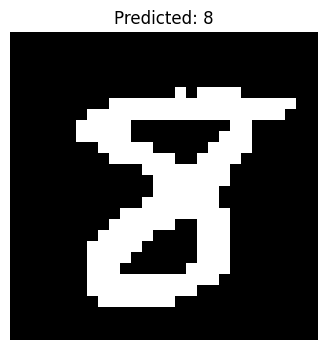

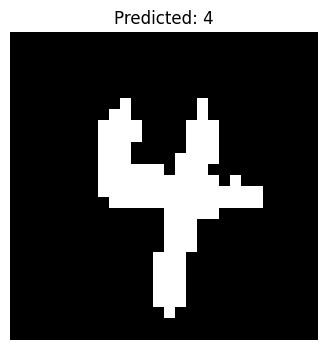

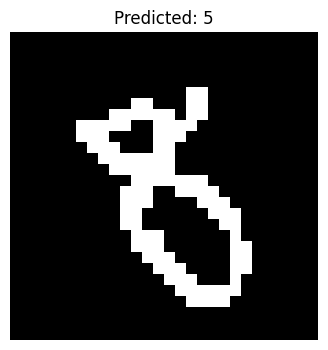

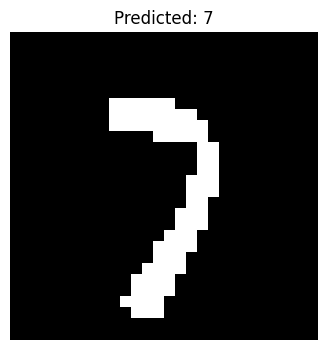

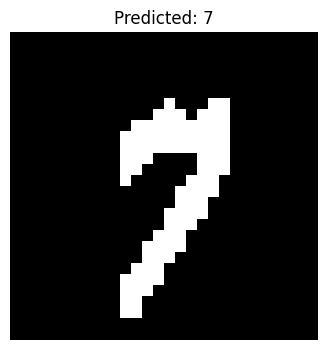


Inspecting clauses...
Clause 0 weights: [1 1 1 1 1 1 1 1 1 1]
Clause 1 weights: [ 707259391 2709520303 2482503679 2814771199 4057333759 3512598527
   68681727     393215 1753552813 4221416255]


IndexError: tuple index out of range

In [1]:
# ================================
# 📦 INSTALLS
# ================================
!pip install pyTsetlinMachine numpy scikit-learn matplotlib opencv-python tqdm

# ================================
# 📦 IMPORTS
# ================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from pyTsetlinMachine.tm import MultiClassConvolutionalTsetlinMachine2D

# ================================
# ⚙️ CONFIG (PAPER SETTINGS)
# ================================
CLAUSES = 2500
T = 3125
S = 10
PATCH_SIZE = (10, 10)
EPOCHS = 10

# ================================
# 📥 LOAD MNIST (same as paper)
# ================================
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values.reshape(-1, 28, 28)
y = mnist.target.astype(int)

# Normalize
X = X / 255.0

# ================================
# 🔲 BINARIZATION (paper uses thresholding)
# ================================
def binarize_images(X, threshold=0.5):
    return (X > threshold).astype(np.uint8)

X_bin = binarize_images(X)

# ================================
# ✂️ TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.2, random_state=42
)

# ================================
# 🧠 INITIALIZE MODEL
# ================================
print("Initializing CTM...")

tm = MultiClassConvolutionalTsetlinMachine2D(
    number_of_clauses=CLAUSES,
    T=T,
    s=S,
    patch_dim=PATCH_SIZE
)

# ================================
# 🏋️ TRAINING
# ================================
print("Training...")

for epoch in range(EPOCHS):
    tm.fit(X_train, y_train, epochs=1, incremental=True)

    y_pred = tm.predict(X_train)
    acc = accuracy_score(y_train, y_pred)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {acc:.4f}")

# ================================
# 📊 EVALUATION
# ================================
y_pred = tm.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("\n✅ Test Accuracy:", test_acc)

# ================================
# 🔍 BASIC INTERPRETATION (SIMPLIFIED LOCAL)
# ================================
def visualize_sample(idx):
    img = X_test[idx]
    pred = tm.predict(X_test[idx:idx+1])[0]

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {pred}")
    plt.axis('off')
    plt.show()

# Show few samples
for i in range(5):
    visualize_sample(i)

# ================================
# 🔬 CLAUSE INSPECTION (DEBUG / INTERPRETABILITY)
# ================================
def inspect_clauses(tm, num_clauses=10):
    print("\nInspecting clauses...")
    weights = tm.get_state()[1]

    for i in range(num_clauses):
        print(f"Clause {i} weights:", weights[i][:10])

inspect_clauses(tm)

# ================================
# 🔥 SIMPLE PATCH ACTIVATION MAP (approx local interpretation)
# ================================
def patch_heatmap(image, tm):
    h, w = image.shape
    ph, pw = PATCH_SIZE

    heatmap = np.zeros((h, w))

    for i in range(h - ph):
        for j in range(w - pw):
            patch = image[i:i+ph, j:j+pw]
            patch = patch.reshape(1, ph, pw)

            pred = tm.predict(patch)[0]

            heatmap[i:i+ph, j:j+pw] += pred

    return heatmap

# visualize heatmap
sample = X_test[0]
heat = patch_heatmap(sample, tm)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(heat, cmap='jet')
plt.title("Approx Interpretation")

plt.show()

# ================================
# 📌 DONE
# ================================
print("\n🚀 Pipeline Complete!")

/bin/bash: /home/priyat/anaconda3/envs/tmu_cuda/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Loading SAR dataset...
Train: (1210, 64, 64) Test: (2425, 64, 64)
Initializing CTM...
Training...
Epoch 1/10 - Train Accuracy: 0.1000
Epoch 2/10 - Train Accuracy: 0.1058
Epoch 3/10 - Train Accuracy: 0.1479
Epoch 4/10 - Train Accuracy: 0.1868
Epoch 5/10 - Train Accuracy: 0.3455
Epoch 6/10 - Train Accuracy: 0.2058
Epoch 7/10 - Train Accuracy: 0.3826
Epoch 8/10 - Train Accuracy: 0.2901
Epoch 9/10 - Train Accuracy: 0.7438
Epoch 10/10 - Train Accuracy: 0.4579

✅ Test Accuracy: 0.2329896907216495


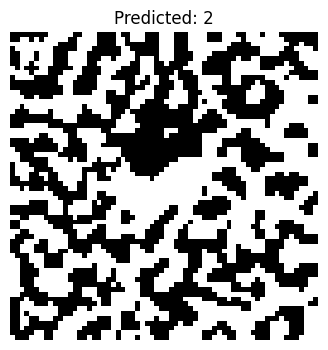

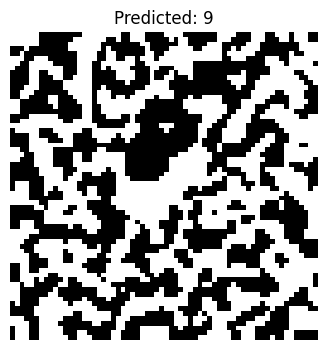

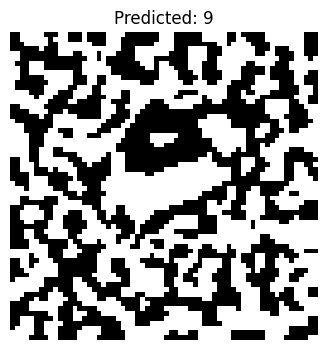

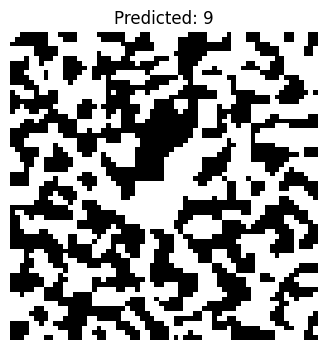

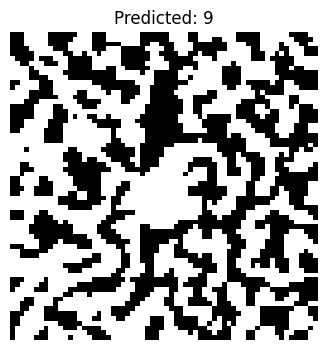


Inspecting clauses...
Clause 0 weights: [1 1 1 1 1 1 1 1 1 1]
Clause 1 weights: [1672350441   65984783 4087794155 1361262517 3228433246 3555720191
 3555720191  739247104  596358135 1782623008]


IndexError: tuple index out of range

In [2]:
# ================================
# 📦 INSTALLS
# ================================
!pip install pyTsetlinMachine numpy scikit-learn matplotlib opencv-python tqdm

# ================================
# 📦 IMPORTS
# ================================
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

from sklearn.metrics import accuracy_score

from pyTsetlinMachine.tm import MultiClassConvolutionalTsetlinMachine2D

# ================================
# ⚙️ CONFIG
# ================================
CLAUSES = 2500
T = 3125
S = 10
PATCH_SIZE = (10, 10)
EPOCHS = 10
IMG_SIZE = 64

BASE_DIR = "MSTAR-10-Classes"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

TRAIN_PER_CLASS = 121   # optional (set None to use all)

# ================================
# 📥 LOAD SAR DATASET (YOUR FORMAT)
# ================================
def load_sar_split(folder, limit_per_class=None):
    images = []
    labels = []

    classes = sorted(os.listdir(folder))

    for label, cname in enumerate(classes):
        class_path = os.path.join(folder, cname)

        if not os.path.isdir(class_path):
            continue

        paths = glob(os.path.join(class_path, "*"))

        if limit_per_class:
            paths = random.sample(paths, min(limit_per_class, len(paths)))

        for p in paths:
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

print("Loading SAR dataset...")

X_train, y_train = load_sar_split(TRAIN_DIR, TRAIN_PER_CLASS)
X_test, y_test   = load_sar_split(TEST_DIR)

print("Train:", X_train.shape, "Test:", X_test.shape)

# ================================
# 🧪 PREPROCESSING (SAR-SPECIFIC)
# ================================
def preprocess_sar(X):
    processed = []

    for img in X:
        # Speckle noise reduction
        img = cv2.GaussianBlur(img, (5,5), 0)

        # Normalize
        img = img.astype(np.float32) / 255.0

        # Contrast enhancement
        img = cv2.equalizeHist((img * 255).astype(np.uint8)) / 255.0

        processed.append(img)

    return np.array(processed)

X_train = preprocess_sar(X_train)
X_test  = preprocess_sar(X_test)

# ================================
# 🔲 BINARIZATION (ADAPTIVE → IMPORTANT)
# ================================
def adaptive_binarize(X):
    out = []

    for img in X:
        img_uint8 = (img * 255).astype(np.uint8)

        binary = cv2.adaptiveThreshold(
            img_uint8,
            1,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11,
            2
        )

        out.append(binary)

    return np.array(out, dtype=np.uint8)

X_train = adaptive_binarize(X_train)
X_test  = adaptive_binarize(X_test)

# ================================
# 🧠 INITIALIZE MODEL
# ================================
print("Initializing CTM...")

tm = MultiClassConvolutionalTsetlinMachine2D(
    number_of_clauses=CLAUSES,
    T=T,
    s=S,
    patch_dim=PATCH_SIZE
)

# ================================
# 🏋️ TRAINING
# ================================
print("Training...")

for epoch in range(EPOCHS):
    tm.fit(X_train, y_train, epochs=1, incremental=True)

    y_pred = tm.predict(X_train)
    acc = accuracy_score(y_train, y_pred)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {acc:.4f}")

# ================================
# 📊 EVALUATION
# ================================
y_pred = tm.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("\n✅ Test Accuracy:", test_acc)

# ================================
# 🔍 VISUALIZATION
# ================================
def visualize_sample(idx):
    img = X_test[idx]
    pred = tm.predict(X_test[idx:idx+1])[0]

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {pred}")
    plt.axis('off')
    plt.show()

for i in range(5):
    visualize_sample(i)

# ================================
# 🔬 CLAUSE INSPECTION
# ================================
def inspect_clauses(tm, num_clauses=10):
    print("\nInspecting clauses...")
    weights = tm.get_state()[1]

    for i in range(num_clauses):
        print(f"Clause {i} weights:", weights[i][:10])

inspect_clauses(tm)

# ================================
# 🔥 PATCH HEATMAP (INTERPRETATION)
# ================================
def patch_heatmap(image, tm):
    h, w = image.shape
    ph, pw = PATCH_SIZE

    heatmap = np.zeros((h, w))

    for i in range(h - ph):
        for j in range(w - pw):
            patch = image[i:i+ph, j:j+pw]
            patch = patch.reshape(1, ph, pw)

            pred = tm.predict(patch)[0]
            heatmap[i:i+ph, j:j+pw] += pred

    return heatmap

sample = X_test[0]
heat = patch_heatmap(sample, tm)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(heat, cmap='jet')
plt.title("Interpretation")

plt.show()

# ================================
# 📌 DONE
# ================================
print("\n🚀 SAR CTM Pipeline Complete!")